+++ ASK FILLED at 70827.97 | Inventory: -1
--- BID FILLED at 70802.04 | Inventory: 0
--- BID FILLED at 70793.53 | Inventory: 1
+++ ASK FILLED at 70851.57 | Inventory: 0
+++ ASK FILLED at 70860.37 | Inventory: -1
+++ ASK FILLED at 70860.88 | Inventory: -2
+++ ASK FILLED at 70868.58 | Inventory: -3
+++ ASK FILLED at 70869.08 | Inventory: -4
--- BID FILLED at 70857.94 | Inventory: -3
+++ ASK FILLED at 70872.78 | Inventory: -4
--- BID FILLED at 70869.63 | Inventory: -3
--- BID FILLED at 70850.74 | Inventory: -2
--- BID FILLED at 70854.53 | Inventory: -1
--- BID FILLED at 70845.63 | Inventory: 0
+++ ASK FILLED at 70831.57 | Inventory: -1
--- BID FILLED at 70845.23 | Inventory: 0
--- BID FILLED at 70833.28 | Inventory: 1
+++ ASK FILLED at 70838.32 | Inventory: 0
+++ ASK FILLED at 70842.22 | Inventory: -1
--- BID FILLED at 70843.68 | Inventory: 0
+++ ASK FILLED at 70853.12 | Inventory: -1
--- BID FILLED at 70845.18 | Inventory: 0
--- BID FILLED at 70837.78 | Inventory: 1
+++ ASK FILLED at 708

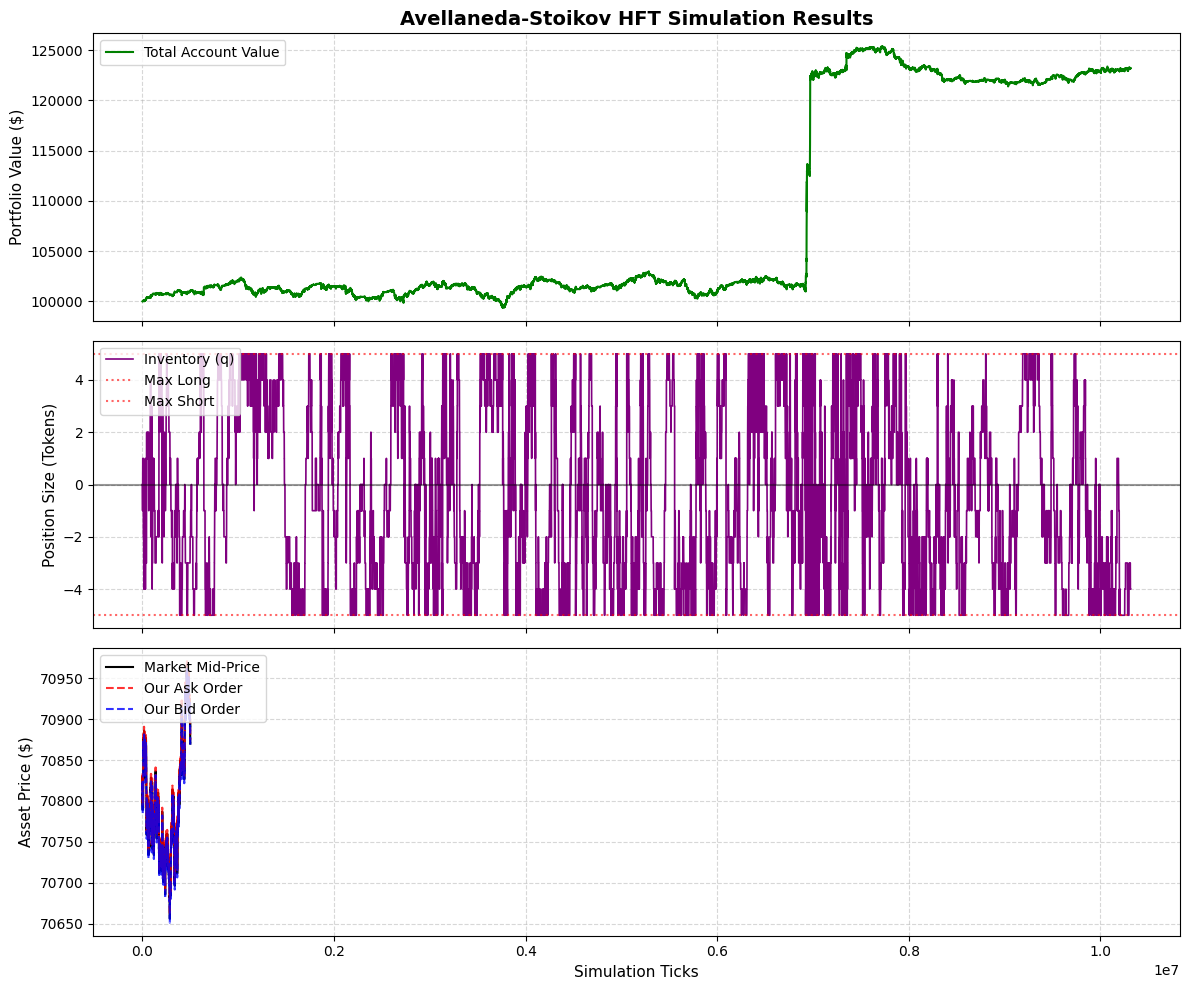

: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("./BTCUSDT-bookTicker-2024-03-29/BTCUSDT-bookTicker-2024-03-29.csv")
df["spot_price"] = (df.best_ask_price + df.best_bid_price) / 2

# Initialize portfolio state
inventory_q = 0         
cash = 100000.0         
risk_factor = 0.1
kappa = 150.0  # FIX: Increased from 1.5 to 150 to match tight crypto order book depth

# Trackers for plotting
equity_curve = []
inventory_history = []
price_ask_list = []  # Explicitly tracking for the micro-chart
price_bid_list = []  # Explicitly tracking for the micro-chart

# Extract arrays
spot_prices = df["spot_price"].to_numpy()
best_bids = df["best_bid_price"].to_numpy()
best_asks = df["best_ask_price"].to_numpy()
event_times = df["event_time"].to_numpy()

end_time = event_times[-1]
start_time = event_times[0]
total_time = (end_time - start_time)

MAX_INVENTORY = 5  
active_bid = None
active_ask = None

# FIX: Increased the loop range from 2,000 to 50,000 ticks to see real market movements
start_loop = 1001
end_loop = min(5000000, len(spot_prices) - 1)
end_max = len(spot_prices) - 1
for i in range(start_loop, end_max):
    current_spot_price = spot_prices[i]
    current_market_bid = best_bids[i]
    current_market_ask = best_asks[i]
    
    # ----------------------------------------------------
    # PART A: SIMULATE FILLS FROM PREVIOUS TICK'S ORDERS
    # ----------------------------------------------------
    if active_bid is not None:
        if current_market_bid <= active_bid and inventory_q < MAX_INVENTORY:
            inventory_q += 1
            cash -= active_bid
            print(f"--- BID FILLED at {active_bid:.2f} | Inventory: {inventory_q}")
            
    if active_ask is not None:
        if current_market_ask >= active_ask and inventory_q > -MAX_INVENTORY:
            inventory_q -= 1
            cash += active_ask
            print(f"+++ ASK FILLED at {active_ask:.2f} | Inventory: {inventory_q}")

    # ----------------------------------------------------
    # PART B: TRACK METRICS & PERFORMANCE
    # ----------------------------------------------------
    current_equity = cash + (inventory_q * current_spot_price)
    equity_curve.append(current_equity)
    inventory_history.append(inventory_q)

    # ----------------------------------------------------
    # PART C: RUN MATH TO GENERATE NEW ORDERS FOR NEXT TICK
    # ----------------------------------------------------
    hund_values = spot_prices[i - 1000: i]
    variance = np.var((hund_values / current_spot_price) * 100)
    
    time_left = end_time - event_times[i]
    t_remaining = time_left / total_time
    
    current_spot_norm = 100.0
    reservation_price = current_spot_norm - (inventory_q * risk_factor * variance * t_remaining)
    delta = (1 / 2) * risk_factor * variance * t_remaining + (1 / risk_factor) * np.log(1 + (risk_factor / kappa))
    
    price_ask_norm = reservation_price + delta
    price_bid_norm = reservation_price - delta
    
    active_ask = (price_ask_norm / 100.0) * current_spot_price
    active_bid = (price_bid_norm / 100.0) * current_spot_price
    
    # FIX: Append calculated quotes to lists so matplotlib can visualize them
    price_ask_list.append(active_ask)
    price_bid_list.append(active_bid)

# ----------------------------------------------------
# VISUALIZATION DASHBOARD
# ----------------------------------------------------
analyzed_spot_prices = spot_prices[start_loop:end_loop]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1: Equity Curve
ax1.plot(equity_curve, color='green', linewidth=1.5, label='Total Account Value')
ax1.set_title('Avellaneda-Stoikov HFT Simulation Results', fontsize=14, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

# Plot 2: Inventory Tracking
ax2.plot(inventory_history, color='purple', linewidth=1.2, label='Inventory (q)')
ax2.axhline(0, color='black', linestyle='-', alpha=0.4) 
ax2.axhline(MAX_INVENTORY, color='red', linestyle=':', alpha=0.6, label='Max Long') 
ax2.axhline(-MAX_INVENTORY, color='red', linestyle=':', alpha=0.6, label='Max Short') 
ax2.set_ylabel('Position Size (Tokens)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left')

# Plot 3: Zoomed Quote Behavior (First 500 entries of the simulation window)
zoom = 500000
ax3.plot(analyzed_spot_prices[:zoom], color='black', label='Market Mid-Price', linewidth=1.5)
ax3.plot(price_ask_list[:zoom], color='red', label='Our Ask Order', linestyle='--', alpha=0.8)
ax3.plot(price_bid_list[:zoom], color='blue', label='Our Bid Order', linestyle='--', alpha=0.8)
ax3.set_ylabel('Asset Price ($)', fontsize=11)
ax3.set_xlabel('Simulation Ticks', fontsize=11)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [3]:
inventory_history[-1]

-5